In [53]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import planetary_computer as pc
from pystac_client import Client

Planetary Computer is Microsoft's free satellite data service. It hosts the entire Sentinel-2 archive — every image ever taken by the satellite, going back to 2015, globally available at no cost.

modifier=pc.sign_inplace: a security token that says you are allowed to read the file

In [54]:
# Connect to Microsoft's free satellite data catalog
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

print("Connected to Planetary Computer")

Connected to Planetary Computer


A bounding box is a small rectangle around your point. We add and subtract 0.01 degrees in each direction — that is about 1 kilometer. 

In [55]:
# Our Iowa cornfield — we will use this location all project
lat = 41.878
lon = -93.097

# A small rectangle around our point
# Format: [min_lon, min_lat, max_lon, max_lat]
bbox = [lon - 0.01, lat - 0.01, lon + 0.01, lat + 0.01]

# Search — ask for images in July 2023, take just one result
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2023-07-01/2023-07-31",
    max_items=1,
)

# Get the result
items = list(search.items())
item = items[0]

print("Found image from:", item.datetime.date())
print("Cloud cover:     ", item.properties["eo:cloud_cover"], "%")
print("Image ID:        ", item.id)

Found image from: 2023-07-30
Cloud cover:      2.443376 %
Image ID:         S2B_MSIL2A_20230730T165849_R069_T15TVG_20241019T075408


Each search result contains URLs for every band. Let's get the URL for Band 4 (Red) and see what it looks like

In [56]:
# Get the signed URL for Band 4 (Red)
b04_url = item.assets["B04"].href

# Print just the beginning — the full URL is very long
print("Band 4 URL starts with:")
print(b04_url[:80], "...")

Band 4 URL starts with:
https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/15/T/VG/2023/07/30/S2B ...


Now open the file with rasterio. This does not download the whole image — it reads the file header, which contains shape, coordinate system, and value ranges. Opening a GeoTIFF is fast even when the file itself is large.
Three things to notice here:

Shape is 10980 × 10980. That is the full Sentinel-2 tile — about 110 km × 110 km at 10-meter resolution. Way too large to work with directly. We will read just a small patch around our field in the next step.
Number of bands is 1. This file contains only Band 4. Each band is a separate file in Sentinel-2. That is why you need to download them individually and stack them yourself.
Data type is uint16. Values are integers from 0 to 65535, not floating-point percentages. The actual reflectance (0 to 1) is this value divided by 10,000. You will do that conversion shortly.

In [57]:
with rasterio.open(b04_url) as src:
    print("Image shape:      ", src.shape)
    print("Number of bands:  ", src.count)
    print("Coordinate system:", src.crs)
    print("Data type:        ", src.dtypes[0])

Image shape:       (10980, 10980)
Number of bands:   1
Coordinate system: EPSG:32615
Data type:         uint16


Reading all 10,980 × 10,980 pixels would use a lot of memory and be slow. Cloud-Optimized GeoTIFFs (COGs) let you read just a small rectangle — called a window — without downloading the whole file.

You now have a 256×256 numpy array of real satellite pixel values. Each number represents how much red light was reflecting off that patch of earth's surface when the satellite passed overhead in July 2023.

In [58]:
with rasterio.open(b04_url) as src:
    # Read a 256×256 window starting at row 5000, column 5000
    # This is roughly the center of the image tile
    window = rasterio.windows.Window(
        col_off=5000,   # start column
        row_off=5000,   # start row
        width=256,
        height=256
    )

    # read(1) means: read band number 1
    data = src.read(1, window=window)

print("Array shape:", data.shape)
print("Data type:  ", data.dtype)
print("Min value:  ", data.min())
print("Max value:  ", data.max())

Array shape: (256, 256)
Data type:   uint16
Min value:   1092
Max value:   8296


The raw integer values (1092, 8296, etc.) are not very meaningful on their own. Divide by 10,000 to get actual surface reflectance — a number between 0 and 1 where 0 means "absorbed all light" and 1 means "reflected all light."

We need to better understand what 0.149 mean in terms of stress. 

In [59]:
# Convert raw integer → surface reflectance
reflectance = data.astype(np.float32) / 10000.0

print("After conversion:")
print("Min value:", reflectance.min().round(4))
print("Max value:", reflectance.max().round(4))
print("Mean value:", reflectance.mean().round(4))

After conversion:
Min value: 0.1092
Max value: 0.8296
Mean value: 0.149


That ratio is the signal. A stressed field would show NIR reflectance dropping toward the Red value. NDVI is just a normalized version of this ratio.

In [60]:
# Same image (item), but Band 8 this time
b08_url = item.assets["B08"].href

with rasterio.open(b08_url) as src:
    
    window = rasterio.windows.Window(5000, 5000, 256, 256)
    nir_data = src.read(1, window=window).astype(np.float32) / 10000.0

print("NIR mean reflectance:", nir_data.mean().round(4))
print("Red mean reflectance:", reflectance.mean().round(4))

NIR mean reflectance: 0.4509
Red mean reflectance: 0.149


A grayscale image of real earth surface. Dark patches are healthy vegetation — plants absorbing red light. Bright patches are bare soil or roads — reflecting a lot of red light back. If you see a mostly dark image with some brighter lines and patches, you are looking at an Iowa agricultural landscape from 500 km above the earth.

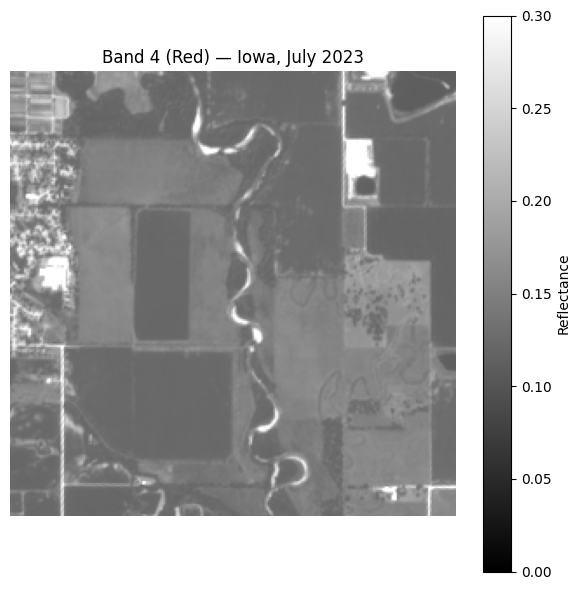

In [61]:
plt.figure(figsize=(6, 6))

plt.imshow(
    reflectance,
    cmap='gray',
    vmin=0,
    vmax=0.3    # clip at 0.3 so the contrast is visible
)
# Why vmax=0.3?
# If you leave out vmax, matplotlib will auto-scale to the brightest pixel, which can wash out the contrast in dark areas.
# Setting vmax=0.3 means "treat 0.3 reflectance as white." Anything above 0.3 clips to white. 
# This makes the vegetation patterns easier to see. You will use this technique throughout the project
plt.title('Band 4 (Red) — Iowa, July 2023')
plt.colorbar(label='Reflectance')
plt.axis('off')
plt.tight_layout()
plt.show()

Load Band 8 (Near-Infrared) for the same window and put them next to each other. Remember: healthy plants absorb red (Band 4) but reflect near-infrared (Band 8). So the same field should look dark in Band 4 and bright in Band 8.

The same spatial patterns in reverse. Areas that are dark in Band 4 are bright in Band 8 — those are the healthy crop fields. Areas that are bright in Band 4 (roads, bare soil) are dull in Band 8. This inversion is exactly the plant signature that NDVI captures. You are seeing the physics of photosynthesis expressed in two satellite images taken at the same moment

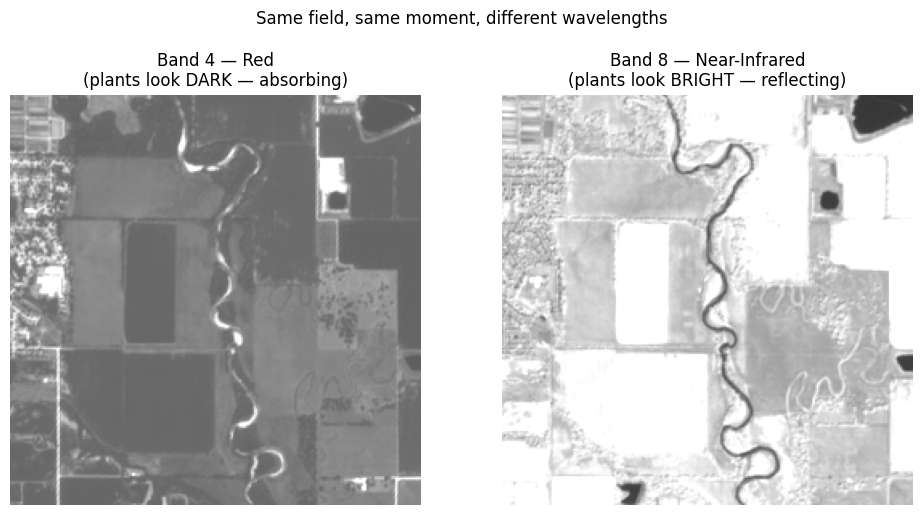

In [62]:
# Red vs NIR side-by-side (same field, same moment)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: Band 4 (Red) — plants absorb, so they look dark
axes[0].imshow(reflectance, cmap='gray', vmin=0, vmax=0.3)
axes[0].set_title('Band 4 — Red\n(plants look DARK — absorbing)')
axes[0].axis('off')

# Right: Band 8 (NIR) — plants reflect, so they look bright
axes[1].imshow(nir_data, cmap='gray', vmin=0, vmax=0.5)
axes[1].set_title('Band 8 — Near-Infrared\n(plants look BRIGHT — reflecting)')
axes[1].axis('off')

plt.suptitle('Same field, same moment, different wavelengths', y=1.02)
plt.tight_layout()
plt.show()

Compute NDVI: Values below 0.3 would indicate stress or sparse vegetation.

In [63]:
# NDVI formula: (NIR - Red) / (NIR + Red)
# The 1e-8 prevents division by zero in dark pixels
ndvi = (nir_data - reflectance) / (nir_data + reflectance + 1e-8)

print("NDVI range:", ndvi.min().round(3), "to", ndvi.max().round(3))
print("NDVI mean: ", ndvi.mean().round(3))

NDVI range: -0.031 to 0.72
NDVI mean:  0.487


 color image where fields show up as green (healthy, high NDVI) and roads, bare soil, and water show up as yellow or red (low NDVI). This is a real vegetation health map of an Iowa agricultural landscape, generated from two lines of arithmetic applied to satellite data you fetched 

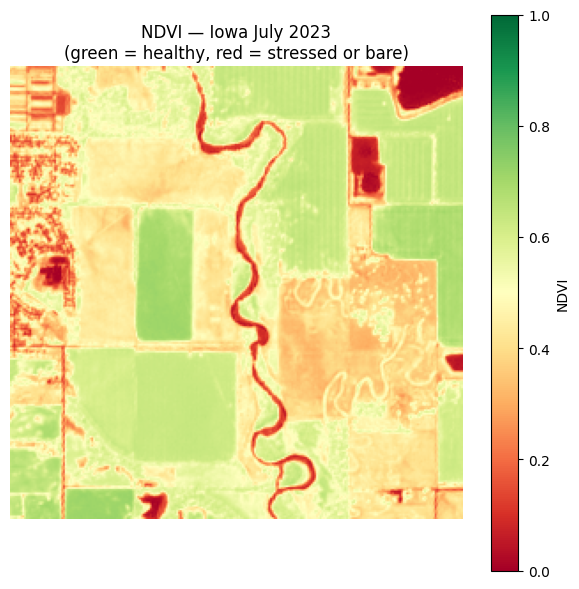

In [64]:
plt.figure(figsize=(6, 6))
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1)
plt.title('NDVI — Iowa July 2023\n(green = healthy, red = stressed or bare)')
plt.colorbar(label='NDVI')
plt.axis('off')
plt.tight_layout()
plt.show()